# Dark photon lifetime — acceptance-corrected cτ

The companion `lifetime_validation.ipynb` recovers the proper cτ two ways: the **histogram
mean** of the proper-decay-length distribution (exact for an untruncated exponential) and a
**core-slope fit** (the exponential slope of the un-truncated low-x core). Both are unbiased
only while the distribution is faithful. At long lifetimes the generator caps the *lab-frame*
decay length at a fixed radius `R_max` (found below to be ~8 m): a dark photon that would
decay beyond `R_max` in the lab is dropped, which removes the high-x tail of the *proper*
distribution and biases the mean (and eventually the core-slope fit) low.

### The truncation model

A decay with proper length `x` and boost `βγ` travels `ℓlab = βγ·x` in the lab. It
survives the cap iff `βγ·x < R_max`, i.e. iff `βγ < R_max/x`. The fraction of decays at
proper length `x` that survive is therefore the acceptance

  `ε(x) = P(βγ < R_max/x) = Fβγ(R_max/x)`,

where `Fβγ` is the CDF of the boost distribution. The *observed* proper density is the
intrinsic exponential times this acceptance:

  `dN/dx ∝ exp(−x/cτ) · Fβγ(R_max/x)`.

### Assumptions

1. **Sharp lab cap** — the generator drops decays beyond a single fixed `R_max`
   (validated below: the fitted `R_max` is consistent across the whole grid).
2. **Boost independent of lifetime** — `βγ` is set by the production kinematics (the
   masses), not by cτ, so `Fβγ` for a mass point is measured once from its shortest-cτ
   (faithful) sample and reused for all its lifetimes.
3. **Pure exponential intrinsic decay**, as generated.

Fitting `log(dN/dx) = logA − x/cτ + log Fβγ(R_max/x)` returns both the intrinsic cτ and
the lab cap `R_max`, with their covariance.

In [1]:
import sys, os, importlib
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# put the repo root on sys.path so `from sidm...` resolves to the working tree
sidm_path = os.getcwd().split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)
from sidm.tools import utilities
import lifetime_analysis as la
importlib.reload(la)

utilities.set_plot_style(dpi=110)   # mplhep CMS style + crisp inline figures

In [2]:
output = la.load_grid()                       # full-grid coffea (local cache or EOS)
rows, groups, bg_mean = la.compute_grid(output)
bgs = [bg_mean[k] for k in bg_mean]
print(f"{len(groups)} mass points, {len(rows)} samples; "
      f"<betagamma> in [{min(bgs):.0f}, {max(bgs):.0f}]")

36 mass points, 179 samples; <betagamma> in [16, 2735]


## Every fit, batched by mass point

As in the validation notebook, one panel per mass point with the cτ scan overlaid — but
here the curve is the **acceptance-corrected fit** `exp(−x/cτ)·Fβγ(R_max/x)` and the band
is its ±1σ uncertainty (from the full fit covariance). The fit follows the data through
the turn-over where the lab cap bites, and the legend reports the recovered cτ ± error.

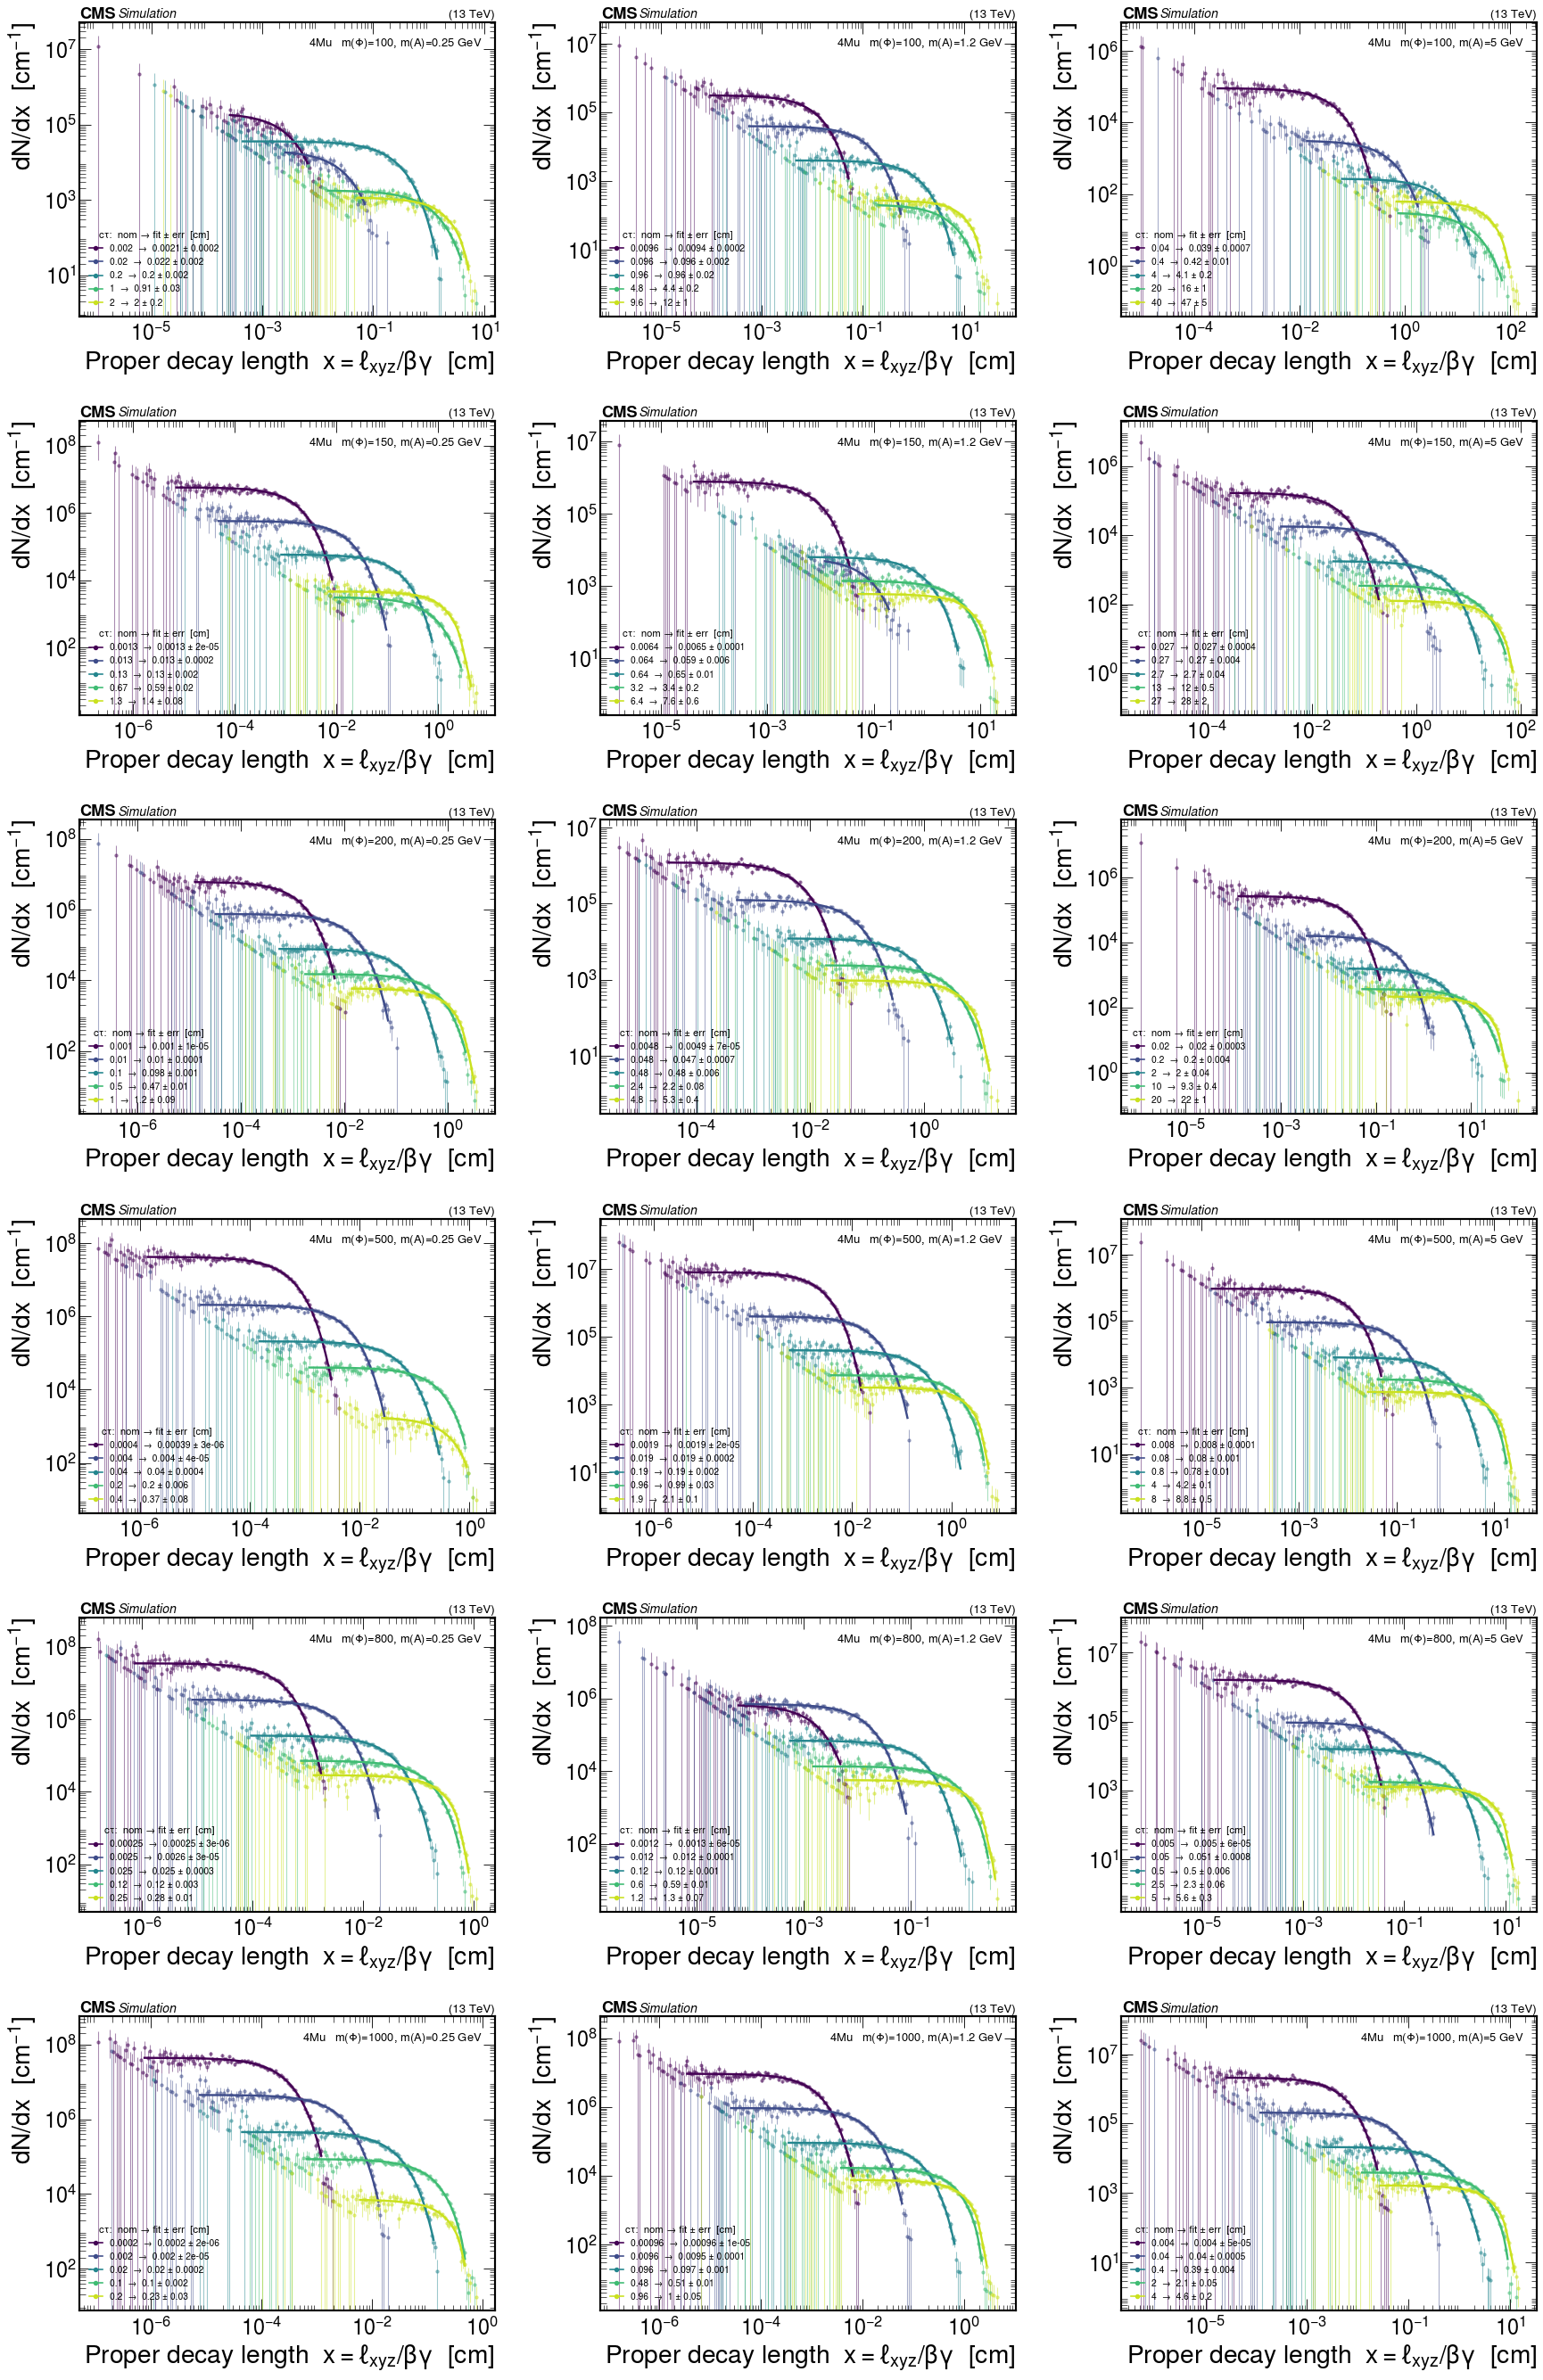

In [3]:
fig = la.plot_fit_grid(output, groups, "4Mu", kind="acceptance")

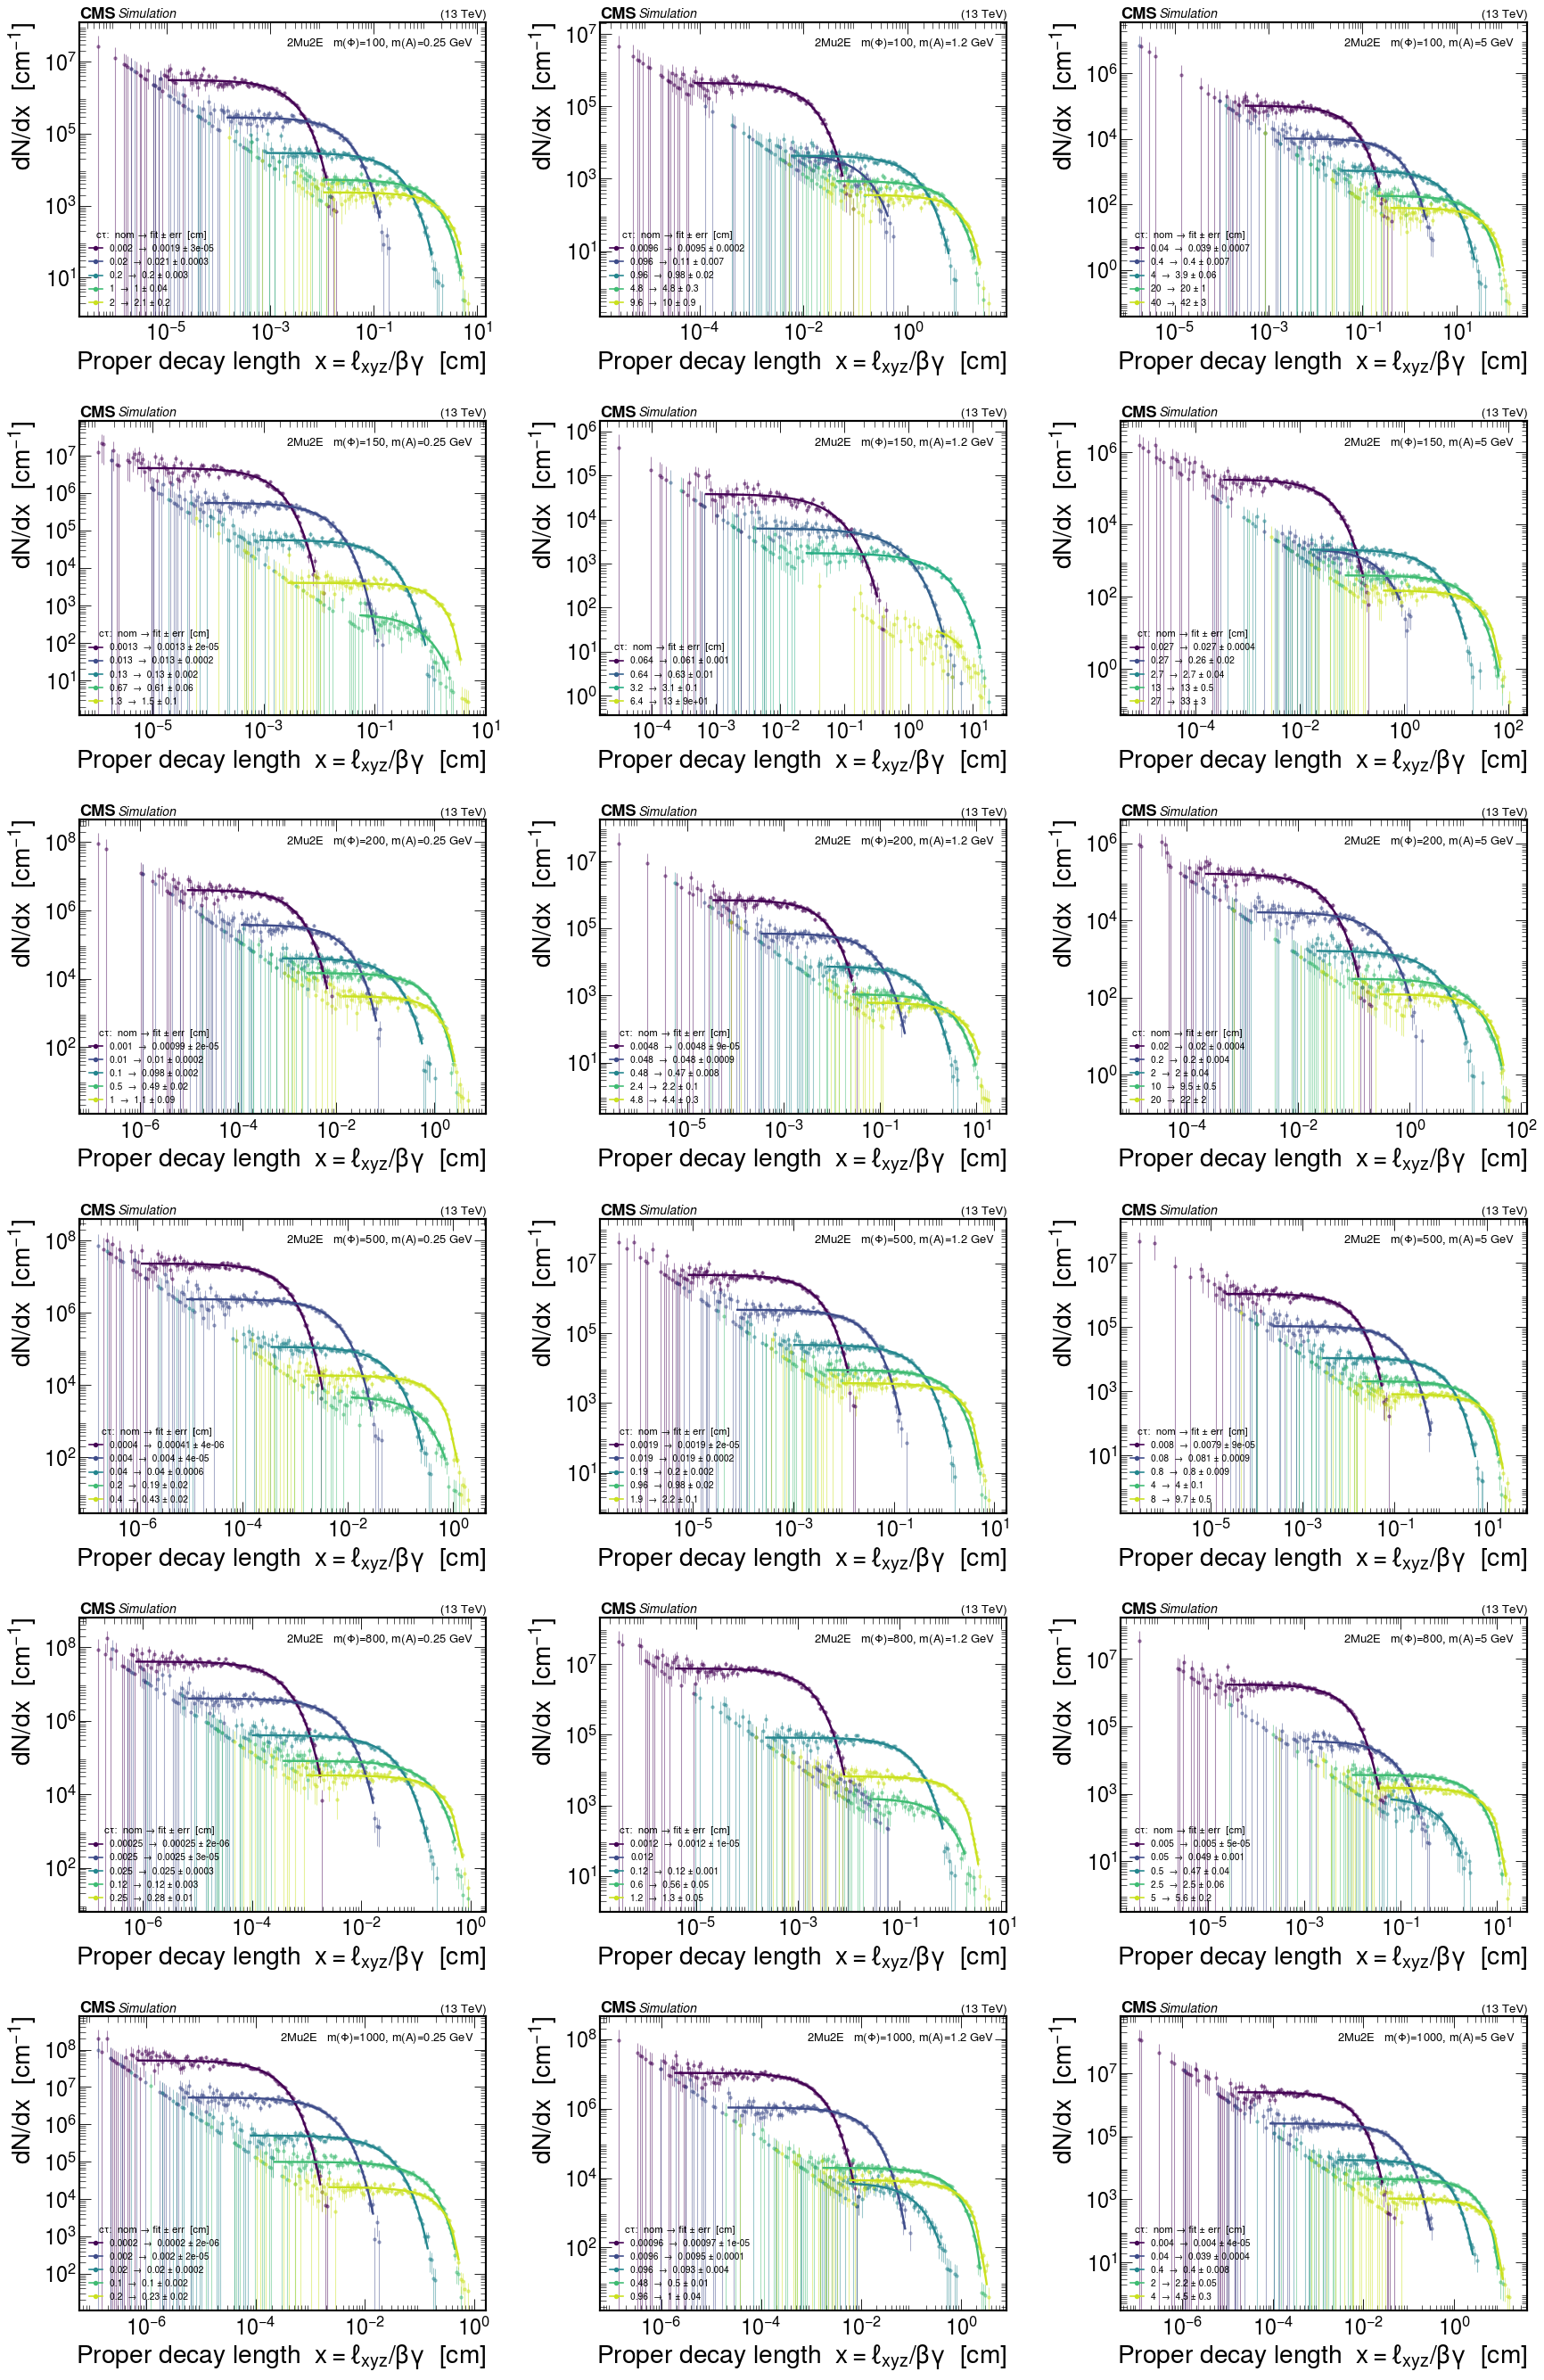

In [4]:
fig = la.plot_fit_grid(output, groups, "2Mu2E", kind="acceptance")

## Recovery across the full grid

The histogram mean (×) falls below 1 once the lab cap truncates the tail; the
acceptance-corrected fit (●, with its ±1σ error bar) folds the cap back in and recovers
`measured / nominal ≈ 1` across the whole grid.

acceptance-corrected, full grid: median measured/nominal = 1.001 (N=178)


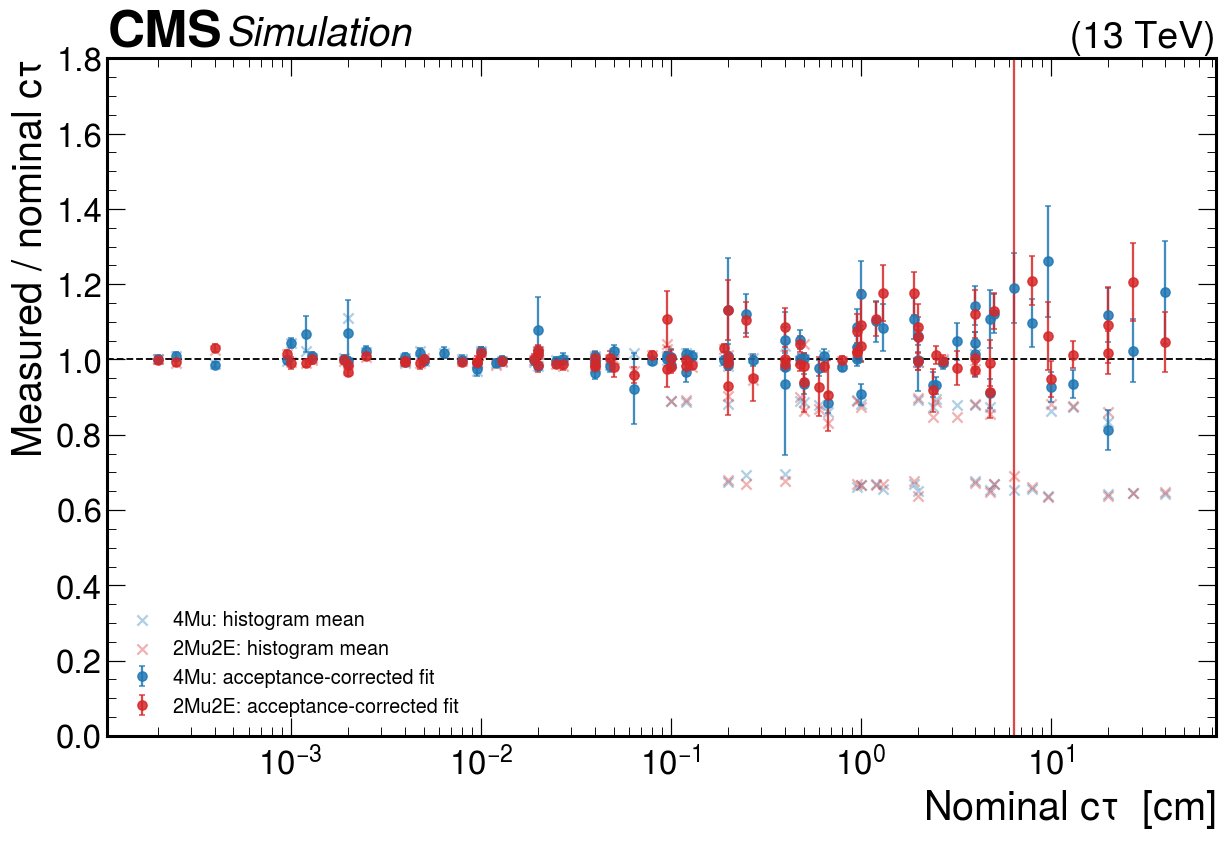

In [5]:
fig, ax = plt.subplots(figsize=(13, 8))
colors = {"4Mu": "#1f77b4", "2Mu2E": "#d62728"}
for ch, c in colors.items():
    rs = [r for r in rows.values() if r["mass_point"][0] == ch]
    nom = np.array([r["nominal"] for r in rs])
    mean = np.array([r["mean"] for r in rs])
    acc_ = np.array([r["acceptance"] for r in rs])
    acce = np.array([r["acceptance_err"] for r in rs])
    ax.scatter(nom, mean / nom, marker="x", s=45, color=c, alpha=0.35,
               label=f"{ch}: histogram mean")
    ax.errorbar(nom, acc_ / nom, yerr=acce / nom, fmt="o", ms=6, color=c, alpha=0.85,
                capsize=2, label=f"{ch}: acceptance-corrected fit")
ax.axhline(1.0, color="k", ls="--", lw=1.2)
ax.set_xscale("log")
ax.set_ylim(0, 1.8)
ax.set_xlabel(r"Nominal $c\tau$  [cm]")
ax.set_ylabel(r"Measured / nominal $c\tau$")
ax.legend(fontsize=13, loc="lower left", framealpha=0.9)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)

corr = [r["acceptance"] / r["nominal"] for r in rows.values()
        if np.isfinite(r["acceptance"])]
print(f"acceptance-corrected, full grid: median measured/nominal "
      f"= {np.median(corr):.3f} (N={len(corr)})")

### The corrected values on their own

The same acceptance-corrected `measured / nominal cτ`, now without the histogram mean
overlaid and on a zoomed scale, so the residual spread of the correction is visible. The
shaded band is ±5%.

acceptance-corrected within +/-5% of nominal: 120/178 samples


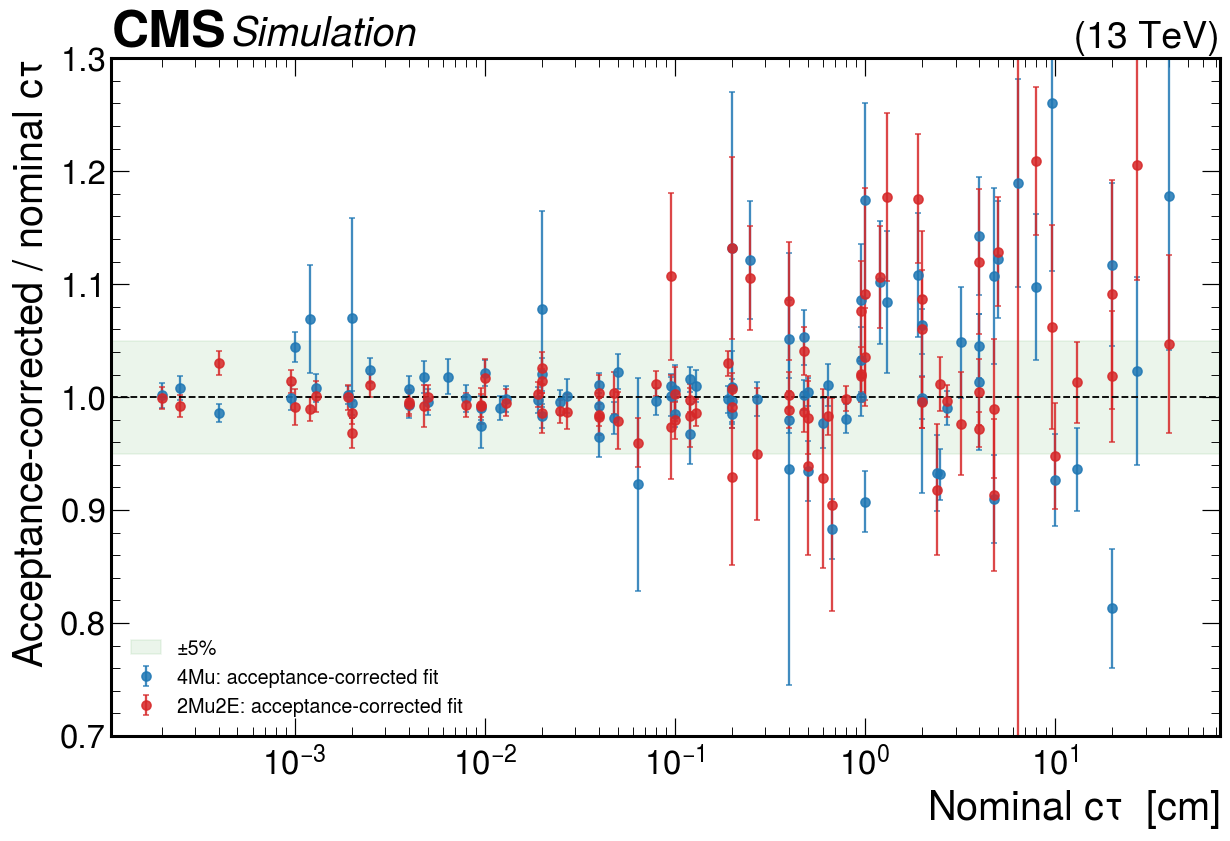

In [6]:
fig, ax = plt.subplots(figsize=(13, 8))
colors = {"4Mu": "#1f77b4", "2Mu2E": "#d62728"}
for ch, c in colors.items():
    rs = [r for r in rows.values()
          if r["mass_point"][0] == ch and np.isfinite(r["acceptance"])]
    nom = np.array([r["nominal"] for r in rs])
    acc_ = np.array([r["acceptance"] for r in rs])
    acce = np.array([r["acceptance_err"] for r in rs])
    ax.errorbar(nom, acc_ / nom, yerr=acce / nom, fmt="o", ms=6, color=c, alpha=0.85,
                capsize=2, label=f"{ch}: acceptance-corrected fit")
ax.axhline(1.0, color="k", ls="--", lw=1.2)
ax.axhspan(0.95, 1.05, color="green", alpha=0.08, label="±5%")
ax.set_xscale("log")
ax.set_ylim(0.7, 1.3)
ax.set_xlabel(r"Nominal $c\tau$  [cm]")
ax.set_ylabel(r"Acceptance-corrected / nominal $c\tau$")
ax.legend(fontsize=13, loc="lower left", framealpha=0.9)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)

within5 = [abs(r["acceptance"] / r["nominal"] - 1) <= 0.05 for r in rows.values()
           if np.isfinite(r["acceptance"])]
print(f"acceptance-corrected within +/-5% of nominal: {sum(within5)}/{len(within5)} samples")

## Is the truncation really a single, sharp, lab-frame cap?

Assumption 1 is the load-bearing one: that one fixed lab-frame decay radius `R_max` cuts
every sample the same way. The two plots below check it.

**Left — is `R_max` universal?** Each point is the `R_max` returned by the fit for one
*heavily*-truncated sample (mean biased below 0.7× nominal). The cut matters: only when a
sample is strongly truncated does the cap actually pin down `R_max` — lightly-truncated
samples leave it nearly unconstrained, with large errors, so they are excluded rather than
allowed to wash out the test. Judged against the ±1σ bars, the points agree on one value
(dashed line = the median), so `R_max` is a single number, not a per-sample knob.

**Right — is the cap in the lab frame, not the proper frame?** A decay of proper length `x`
travels `ℓlab = βγ·x` in the lab, so a more boosted sample (larger `⟨βγ⟩`) maps a given
proper length to a longer lab distance and therefore hits the `R_max` cap at a *smaller*
proper `cτ`: the truncation onset should scale as `1/⟨βγ⟩`. This `βγ`-dependence is the
discriminating test — a *proper*-frame cut would show none. Each point is the onset `cτ` for
one mass point, found by interpolating (in log-cτ) its cτ scan to where the mean first
crosses 0.9× nominal, versus that mass point's `⟨βγ⟩`. The dashed line is **not a fit**: it
is the one-parameter guide `C/⟨βγ⟩` with `C` set to the *median* of the points'
`onset·⟨βγ⟩`. What the plot demonstrates is that `onset·⟨βγ⟩` is constant across the grid
(its 16–84% spread is printed below) — i.e. the onset really does scale as `1/⟨βγ⟩`. The
value of the constant, `C ≈ 0.3 R_max`, is *expected* rather than an independent
measurement: once a lab cap is assumed, the truncated-exponential mean dips to 0.9 at a
fixed fraction of `R_max/⟨βγ⟩`. So this panel confirms the lab-frame *scaling*; the *value*
of `R_max` comes from the fit on the left. Mass points whose shortest-cτ sample is already
truncated (no clean 0.9 crossing in the scan) are not plotted — they are counted below.

median fitted R_max = 825 cm over 36 heavily-truncated samples
onset lab length C = onset*<bg> = 229 cm (16-84%: 195-260 cm) = 0.28 R_max, over 36 mass points (0 skipped: no clean 0.9 crossing)


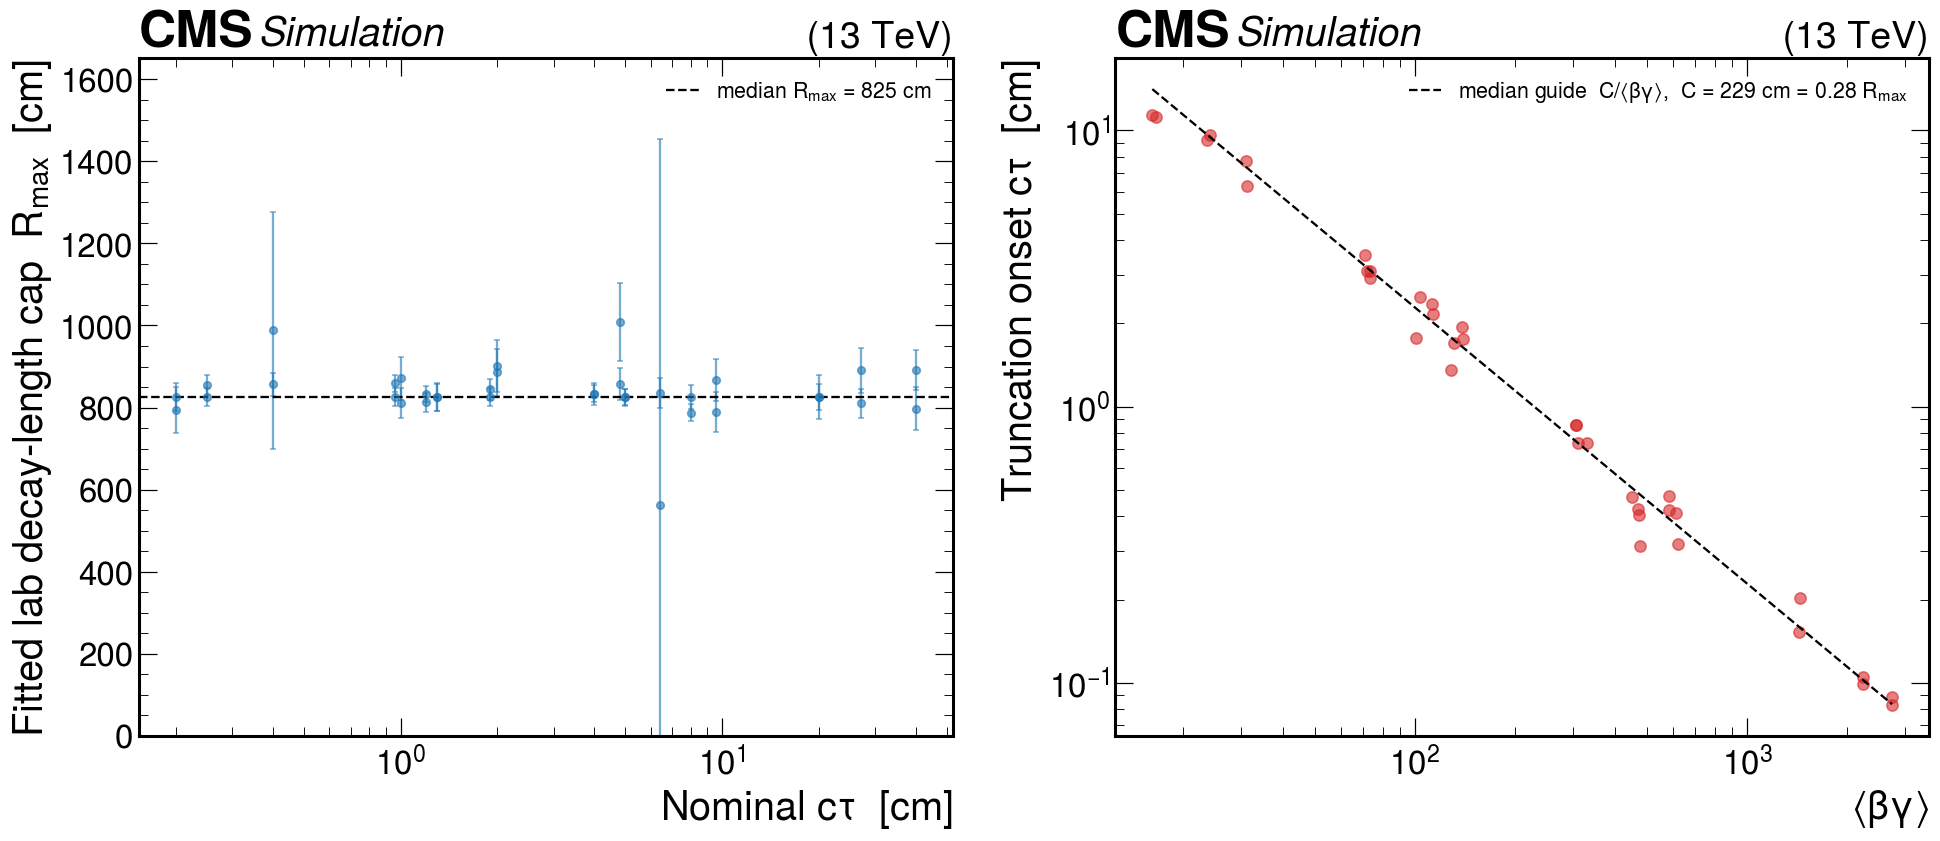

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(21, 8))

# left: fitted R_max for heavily-truncated samples
trunc = [r for r in rows.values()
         if np.isfinite(r["Rmax"]) and np.isfinite(r["Rmax_err"])
         and r["mean"] / r["nominal"] < 0.7]
nomt = np.array([r["nominal"] for r in trunc])
Rm = np.array([r["Rmax"] for r in trunc])
Rme = np.array([r["Rmax_err"] for r in trunc])
med = np.median(Rm)
axL.errorbar(nomt, Rm, yerr=Rme, fmt="o", ms=5, color="#1f77b4", alpha=0.6, capsize=2)
axL.axhline(med, color="k", ls="--", lw=1.5, label=rf"median $R_\mathrm{{max}}$ = {med:.0f} cm")
axL.set_xscale("log")
axL.set_ylim(0, 2 * med)
axL.set_xlabel(r"Nominal $c\tau$  [cm]")
axL.set_ylabel(r"Fitted lab decay-length cap  $R_\mathrm{max}$  [cm]")
axL.legend(fontsize=14)
axL.minorticks_on()
hep.cms.label(ax=axL, data=False)

# right: truncation onset ctau vs <betagamma> -- interpolate each scan to the 0.9 crossing
onset, n_skip = [], 0
for key, samples in groups.items():
    nn = np.array([la.ctau_cm(s) for s in samples])
    rr = np.array([rows[s]["mean"] / rows[s]["nominal"] for s in samples])
    below = np.where(rr < 0.9)[0]
    if not len(below) or below[0] == 0 or rr[below[0]] == rr[below[0] - 1]:
        n_skip += 1   # never dips to 0.9, already truncated at the shortest ctau, or flat
        continue
    i = below[0]
    x0, x1 = np.log(nn[i - 1]), np.log(nn[i])
    y0, y1 = rr[i - 1], rr[i]
    onset.append((bg_mean[key], np.exp(x0 + (0.9 - y0) * (x1 - x0) / (y1 - y0))))
onset = np.array(onset)
prod = onset[:, 0] * onset[:, 1]            # onset * <bg> = lab decay length at the 0.9 onset
C = np.median(prod)
p16, p84 = np.percentile(prod, [16, 84])
axR.scatter(onset[:, 0], onset[:, 1], s=55, color="#d62728", alpha=0.6)
bgg = np.geomspace(onset[:, 0].min(), onset[:, 0].max(), 50)
axR.plot(bgg, C / bgg, "k--", lw=1.5,
         label=rf"median guide  $C/\langle\beta\gamma\rangle$,  $C$ = {C:.0f} cm = {C/med:.2f} $R_\mathrm{{max}}$")
axR.set_xscale("log")
axR.set_yscale("log")
axR.set_xlabel(r"$\langle\beta\gamma\rangle$")
axR.set_ylabel(r"Truncation onset $c\tau$  [cm]")
axR.legend(fontsize=14)
axR.minorticks_on()
hep.cms.label(ax=axR, data=False)

print(f"median fitted R_max = {med:.0f} cm over {len(trunc)} heavily-truncated samples")
print(f"onset lab length C = onset*<bg> = {C:.0f} cm (16-84%: {p16:.0f}-{p84:.0f} cm) "
      f"= {C/med:.2f} R_max, over {len(onset)} mass points ({n_skip} skipped: no clean 0.9 crossing)")

## Diagnostic: where is a strictly-insulated core even possible?

The core-slope fit *avoids* the cap by trimming the truncated tail; the acceptance fit
*models* it. A third option is a **strictly-insulated core** — fit only `x < x_insul =
R_max/βγ_p99`, the proper-length region where *every* event survives (ε = 1), needing no
truncation model at all. The catch is lever arm: to measure the slope `−1/cτ` the window
must span a meaningful fraction of `cτ`, but the insulated window only reaches `R_max/βγ`,
which shrinks with boost. So a strictly-insulated fit is clean **only when `cτ ≲ x_insul/κ`**
(κ ≈ 2–3), with enough events in the window. Here the regime is keyed on the lever arm; a few
green windows have as few as ~10 effective events (the minimum is printed below) and are
correspondingly noisier.

This is a **diagnostic, not a production estimator** — it draws the handoff between the two
estimators we actually use (iterative-trim core-slope at short cτ, acceptance fit at long
cτ). **Left:** the lever-arm ratio `x_insul/cτ` per sample — green where a strictly-insulated
fit is clean (lever arm `≥ κ`), gold/marginal (`≥ 1`), red where there is no insulated lever
arm and the acceptance fit is required. **Right:** the strictly-insulated-core `cτ` cross-check — it
recovers nominal in the green region and falls apart (bias + exploding errors) once the lever
arm is gone, as predicted. (`βγ_p99` is used, not `βγ_max`, which on this grid is pinned to
the β-γ histogram's axis ceiling at high boost.)

R_max = 825 cm, kappa = 2.5;  insulated 107 / marginal 8 / acceptance-only 64  of 179 samples
insulated region (x_insul/ctau >= 2.5): strictly-insulated-core measured/nominal median = 0.995 (N = 106); min events-in-window = 13


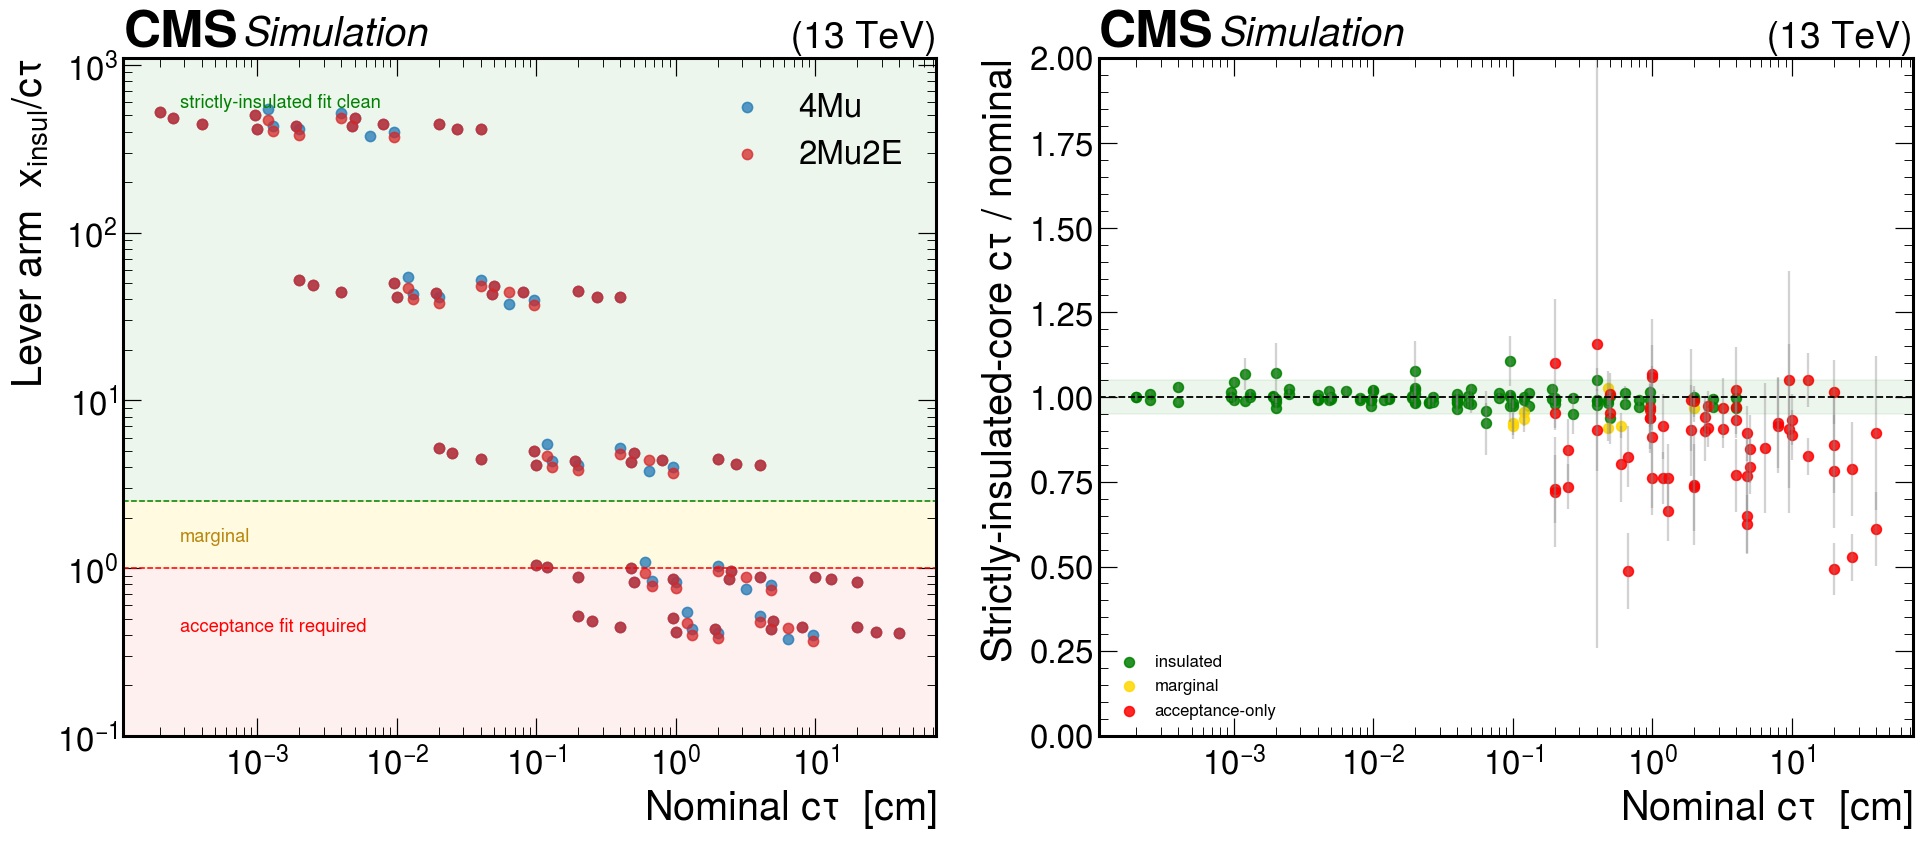

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(21, 8))
Rmax = np.median([r["Rmax"] for r in rows.values() if np.isfinite(r["Rmax"])
                  and np.isfinite(r["Rmax_err"]) and r["mean"] / r["nominal"] < 0.7])
kappa = 2.5

diag = []
for key, samples in groups.items():
    x_insul = Rmax / la.betagamma_pct(output, samples[0], 0.99)
    for s in samples:
        nom = la.ctau_cm(s)
        fit = la.insulated_core_fit(output, s, x_insul)
        diag.append((key[0], nom, x_insul / nom, fit["ctau"], fit["ctau_err"], fit["n"]))
ch = np.array([d[0] for d in diag])
nom = np.array([d[1] for d in diag])
ratio = np.array([d[2] for d in diag])
ins = np.array([d[3] for d in diag])
inse = np.array([d[4] for d in diag])
nwin = np.array([d[5] for d in diag])
regime = np.where(ratio >= kappa, "green", np.where(ratio >= 1, "gold", "red"))

# left: lever-arm map -- which samples a strictly-insulated fit can even do
axL.axhspan(kappa, 1e4, color="green", alpha=0.07)
axL.axhspan(1, kappa, color="gold", alpha=0.12)
axL.axhspan(1e-3, 1, color="red", alpha=0.06)
for c, col in {"4Mu": "#1f77b4", "2Mu2E": "#d62728"}.items():
    m = ch == c
    axL.scatter(nom[m], ratio[m], s=45, color=col, alpha=0.75, label=c)
axL.axhline(kappa, color="green", ls="--", lw=1)
axL.axhline(1, color="red", ls="--", lw=1)
axL.set_xscale("log")
axL.set_yscale("log")
axL.set_ylim(0.1, ratio.max() * 2)
for yv, txt, cc in [(ratio.max() * 1.1, "strictly-insulated fit clean", "green"),
                    (1.55, "marginal", "darkgoldenrod"),
                    (0.45, "acceptance fit required", "red")]:
    axL.text(nom.min() * 1.4, yv, txt, color=cc, fontsize=12, va="center")
axL.set_xlabel(r"Nominal $c\tau$  [cm]")
axL.set_ylabel(r"Lever arm  $x_\mathrm{insul}/c\tau$")
axL.legend(loc="upper right")
axL.minorticks_on()
hep.cms.label(ax=axL, data=False)

# right: strictly-insulated-core ctau cross-check, colored by regime
ok = np.isfinite(ins)
axR.errorbar(nom[ok], (ins / nom)[ok], yerr=(inse / nom)[ok], fmt="none", ecolor="gray", alpha=0.35)
for rg, lab in [("green", "insulated"), ("gold", "marginal"), ("red", "acceptance-only")]:
    m = (regime == rg) & ok
    axR.scatter(nom[m], (ins / nom)[m], s=42, color=rg, alpha=0.85, label=lab)
axR.axhspan(0.95, 1.05, color="green", alpha=0.07)
axR.axhline(1.0, color="k", ls="--", lw=1.2)
axR.set_xscale("log")
axR.set_ylim(0, 2)
axR.set_xlabel(r"Nominal $c\tau$  [cm]")
axR.set_ylabel(r"Strictly-insulated-core $c\tau$ / nominal")
axR.legend(loc="lower left", fontsize=11)
axR.minorticks_on()
hep.cms.label(ax=axR, data=False)

n_i = int((regime == "green").sum())
n_m = int((regime == "gold").sum())
n_a = int((regime == "red").sum())
gsel = (regime == "green") & ok
rec = (ins / nom)[gsel]
med_rec = np.median(rec) if len(rec) else float("nan")
print(f"R_max = {Rmax:.0f} cm, kappa = {kappa};  insulated {n_i} / marginal {n_m} / "
      f"acceptance-only {n_a}  of {len(diag)} samples")
print(f"insulated region (x_insul/ctau >= {kappa}): strictly-insulated-core measured/nominal "
      f"median = {med_rec:.3f} (N = {len(rec)}); "
      f"min events-in-window = {int(nwin[regime == 'green'].min()) if n_i else 0}")

## Result

A single lab decay-length cap (`R_max ≈ 8 m`), consistent across all mass points and both
channels, explains the truncation. Folding it back in as the acceptance `ε(x) =
Fβγ(R_max/x)` recovers the intrinsic proper cτ across the full grid, including the
long-lifetime samples where the histogram mean and core-slope fit break down.